# 1) Chargement des données

Allez, cadeau 😘:

Le but de ce notebook est de construire pas à pas un modèle de détection de faux billets à partir du fichier d'entraînement `billets.csv`.

Point d'attention métier : ici, l'objectif principal est de détecter un maximum de faux billets. On fera donc particulièrement attention au recall de la classe `faux billet`.


In [1]:
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

DATA_PATH = os.path.join("..", "data", "billets.csv")

if not os.path.exists(DATA_PATH):
    print(f"❌ Attention : le fichier '{DATA_PATH}' n'existe pas.")

try:
    df = pd.read_csv(DATA_PATH, sep=";")
    print("✅ Données chargées :", df.shape)
    display(df.head())
except Exception as e:
    print("❌ Erreur lors du chargement :", e)
    print("⚠️ Tu as bien lu le code avant de l'executer ? 😏")


✅ Données chargées : (1500, 7)


,is_genuine,diagonal,height_left,height_right,margin_low,margin_up,length
0,True,171.81,104.86,104.95,4.52,2.89,112.83
1,True,171.46,103.36,103.66,3.77,2.99,113.09
2,True,172.69,104.48,103.50,4.40,2.94,113.16
3,True,171.36,103.91,103.94,3.62,3.01,113.51
4,True,171.73,104.28,103.46,4.04,3.48,112.54


# 2) Analyse exploratoire (EDA)


Là, c'est vous les pro 💪, je vous fais entièrement confiance 😉 !

Pssst (indice) : trouvez des variables corrélées à votre objectif, ça marche mieux 😉.


In [2]:
display(df.info())
display(df.describe(include="all").transpose())

print("Répartition de la cible :")
display(df["is_genuine"].value_counts().rename_axis("is_genuine").to_frame("count"))

print("Valeurs manquantes :")
missing = df.isna().sum().to_frame("missing_count")
missing["missing_ratio_pct"] = (missing["missing_count"] / len(df) * 100).round(2)
display(missing)

print("Doublons :", int(df.duplicated().sum()))



<class 'pandas.DataFrame'>
RangeIndex: 1500 entries, 0 to 1499
Data columns (total 7 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   is_genuine    1500 non-null   bool   
 1   diagonal      1500 non-null   float64
 2   height_left   1500 non-null   float64
 3   height_right  1500 non-null   float64
 4   margin_low    1463 non-null   float64
 5   margin_up     1500 non-null   float64
 6   length        1500 non-null   float64
dtypes: bool(1), float64(6)
memory usage: 71.9 KB


None

,count,unique,top,freq,mean,std,min,25%,50%,75%,max
is_genuine,1500,2,True,1000,NaN,NaN,NaN,NaN,NaN,NaN,NaN
diagonal,1500.0,NaN,NaN,NaN,171.95844,0.305195,171.04,171.75,171.96,172.17,173.01
height_left,1500.0,NaN,NaN,NaN,104.029533,0.299462,103.14,103.82,104.04,104.23,104.88
height_right,1500.0,NaN,NaN,NaN,103.920307,0.325627,102.82,103.71,103.92,104.15,104.95
margin_low,1463.0,NaN,NaN,NaN,4.485967,0.663813,2.98,4.015,4.31,4.87,6.9
margin_up,1500.0,NaN,NaN,NaN,3.151473,0.231813,2.27,2.99,3.14,3.31,3.91
length,1500.0,NaN,NaN,NaN,112.6785,0.87273,109.49,112.03,112.96,113.34,114.44


Répartition de la cible :


,count
is_genuine,
True,1000
False,500


Valeurs manquantes :


,missing_count,missing_ratio_pct
is_genuine,0,0.00
diagonal,0,0.00
height_left,0,0.00
height_right,0,0.00
margin_low,37,2.47
margin_up,0,0.00
length,0,0.00


Doublons : 0


### Distribution des variables

On regarde ici si certaines variables séparent visuellement les vrais et les faux billets.


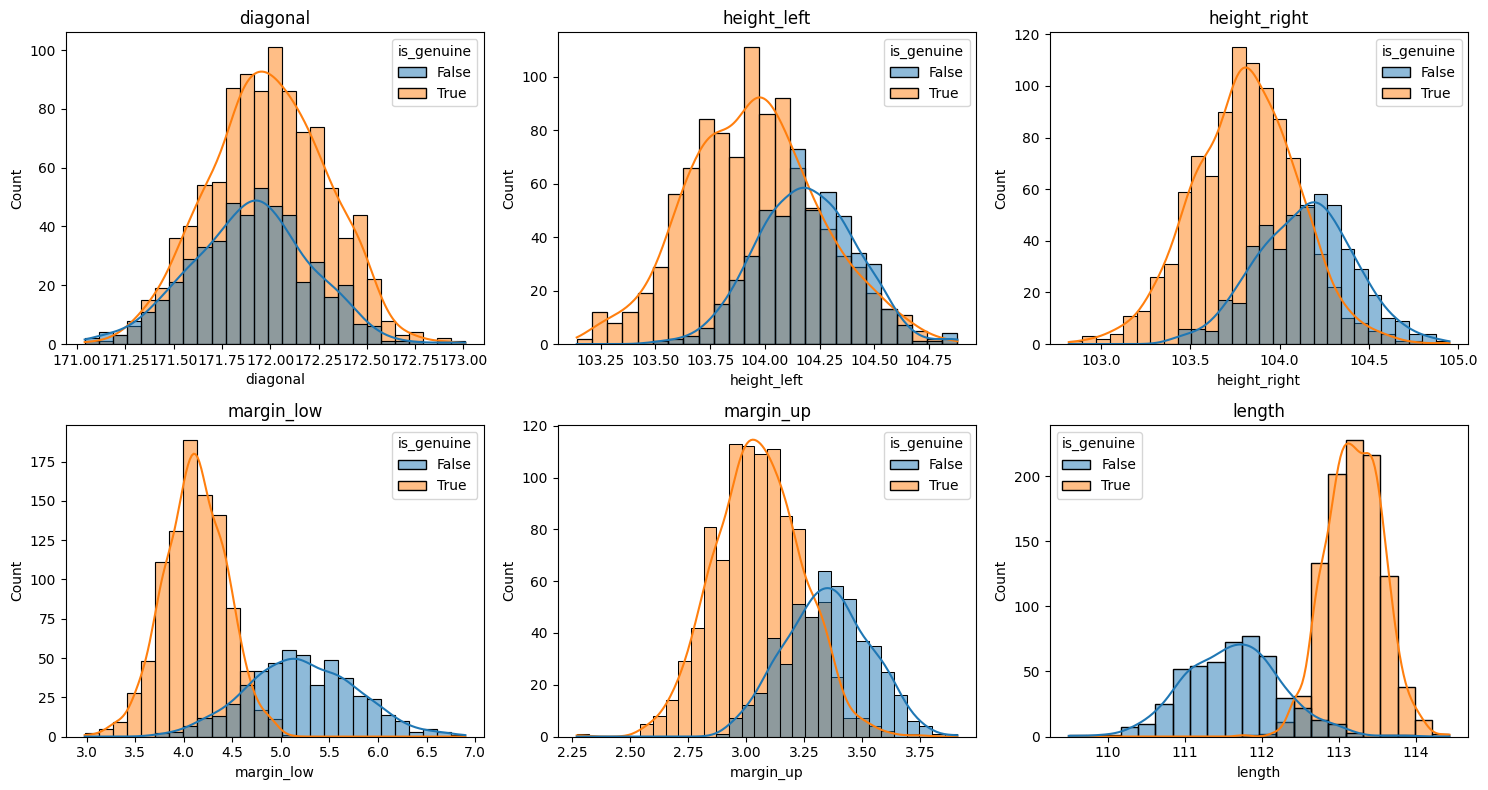

In [3]:
import seaborn as sns
fig, axes = plt.subplots(2, 3, figsize=(15, 8))
variables = ["diagonal", "height_left", "height_right", "margin_low", "margin_up", "length"]

for ax, var in zip(axes.flatten(), variables):
    sns.histplot(data=df, x=var, hue="is_genuine", kde=True, ax=ax)
    ax.set_title(var)

plt.tight_layout()
plt.show()


**Observation** : certaines variables séparent très nettement les vrais et les faux billets, en particulier `length` et `margin_low`, dont les distributions sont quasiment disjointes entre les deux classes. À l'inverse, `height_left`, `height_right` et `diagonal` se chevauchent fortement et semblent peu discriminantes. `margin_up` montre une séparation modérée. Ces observations confirment l'indice du cahier des charges : certaines variables corrélées à la cible seront plus utiles que d'autres pour la prédiction.


### Corrélations entre les variables

Cette matrice aide à repérer quelles variables semblent les plus liées à la cible.


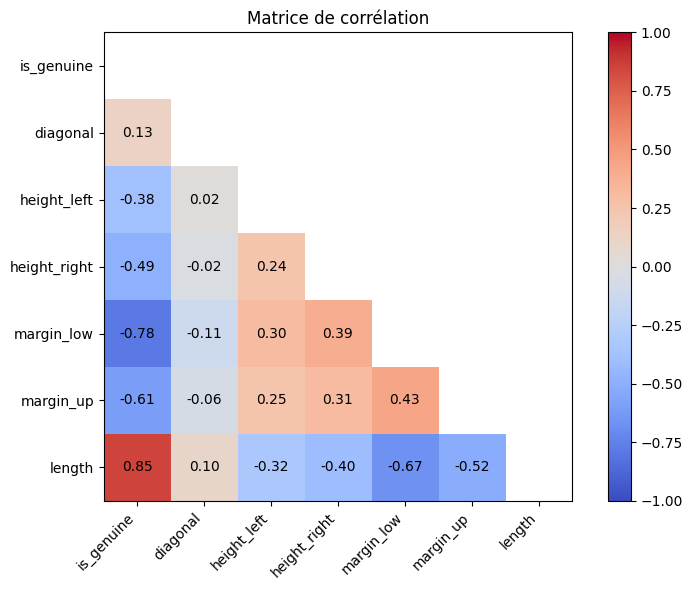

In [4]:
corr = df.copy()
corr["is_genuine"] = corr["is_genuine"].astype(int)
correlation_matrix = corr.corr(numeric_only=True)
mask = np.triu(np.ones_like(correlation_matrix, dtype=bool))
masked = correlation_matrix.mask(mask)

plt.figure(figsize=(8, 6))
plt.imshow(masked, cmap="coolwarm", vmin=-1, vmax=1)
plt.colorbar()
plt.xticks(range(len(correlation_matrix.columns)), correlation_matrix.columns, rotation=45, ha="right")
plt.yticks(range(len(correlation_matrix.index)), correlation_matrix.index)
for i in range(len(correlation_matrix.index)):
    for j in range(len(correlation_matrix.columns)):
        value = masked.iloc[i, j]
        if not pd.isna(value):
            plt.text(j, i, f"{value:.2f}", ha="center", va="center", color="black")
plt.title("Matrice de corrélation")
plt.tight_layout()
plt.show()


**Observation** : `length` (0.85), `margin_low` (-0.78) et `margin_up` (-0.61) sont les variables les plus corrélées à `is_genuine`. À l'inverse, `diagonal` (0.13) semble peu discriminante.

# 3) Prétraitement

Le but est de transformer tes données brutes (les valeurs mesurées des billets) en données que les algorithmes de Machine Learning peuvent comprendre efficacement.


D'abord, il faut séparer les variables explicatives et la cible :

X = les mesures du billet (longueur, hauteur, diagonales…)

y = l’étiquette (vrai ou faux)

➡️ Pourquoi ?
Parce que le modèle doit apprendre à prédire y en fonction de X.

In [5]:
X = df[["diagonal", "height_left", "height_right", "margin_low", "margin_up", "length"]] # Toutes les colonnes sauf la cible
y = df["is_genuine"] # La colonne cible

display(X.head())
display(y.head())


,diagonal,height_left,height_right,margin_low,margin_up,length
0,171.81,104.86,104.95,4.52,2.89,112.83
1,171.46,103.36,103.66,3.77,2.99,113.09
2,172.69,104.48,103.50,4.40,2.94,113.16
3,171.36,103.91,103.94,3.62,3.01,113.51
4,171.73,104.28,103.46,4.04,3.48,112.54


0    True
1    True
2    True
3    True
4    True
Name: is_genuine, dtype: bool

Autre point important : on entraîne toujours le modèle sur un morceau des données, et on teste sur un autre qu’il n’a jamais vu.

➡️ Pourquoi ?
Pour éviter le sur-apprentissage (le modèle apprend par cœur sans savoir généraliser).

In [6]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split( # utilisez train_test_split de la librairy Sklearn
    X,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y,
)

print("Tailles des jeux :")
print("X_train :", X_train.shape)
print("X_test :", X_test.shape)


Tailles des jeux :
X_train : (1200, 6)
X_test : (300, 6)


Que choisir pour imputer les valeurs manquantes ?

**SimpleImputer(strategy="median")**

remplace chaque valeur manquante par une valeur fixe
ici : la médiane de la colonne manquante
c’est simple, rapide, stable
ça ne tient pas compte des autres variables du billet


**KNNImputer(n_neighbors=5)**

remplace une valeur manquante en regardant les billets les plus proches, il estime la valeur manquante à partir des autres colonnes.

c’est plus intelligent en théorie

mais aussi plus complexe, plus lent, et parfois pas meilleur en pratique

In [7]:
from sklearn.impute import KNNImputer
from sklearn.impute import SimpleImputer


#petit test de choix d'imputer
imputer_choice = 1

if imputer_choice == 0:
    # On complète les valeurs manquantes avec la médiane du train.
    imputer = SimpleImputer(strategy="median")
    X_train_filled = pd.DataFrame(imputer.fit_transform(X_train), columns=X_train.columns, index=X_train.index)
    X_test_filled = pd.DataFrame(imputer.transform(X_test), columns=X_test.columns, index=X_test.index)
else:
    #on complète les valeurs manquante à l'aide des valeurs proches (voisins)
    imputer = KNNImputer(n_neighbors=5)
    X_train_filled = pd.DataFrame(imputer.fit_transform(X_train), columns=X_train.columns, index=X_train.index)
    X_test_filled = pd.DataFrame(imputer.transform(X_test), columns=X_test.columns, index=X_test.index)


X_train_filled.isna().sum()   # vérification qu'il n'y a plus de valeurs manquantes

diagonal        0
height_left     0
height_right    0
margin_low      0
margin_up       0
length          0
dtype: int64

Enfin, on met toutes les variables sur la même échelle (moyenne = 0, écart-type = 1).

➡️ Pourquoi ?
Parce que certains modèles, comme le KNN ou la Régression Logistique, sont sensibles aux différences d’échelle.
Sans standardisation, la variable la plus grande numériquement prend trop d’importance.


In [8]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()
# Use scaler on X_train and X_test.
X_train_scaled = pd.DataFrame(
    scaler.fit_transform(X_train_filled),
    columns=X_train.columns,
    index=X_train.index,
)

X_test_scaled = pd.DataFrame(
    scaler.transform(X_test_filled),
    columns=X_test.columns,
    index=X_test.index,
)


# 4) Modélisation

Dans tous domaines, vous ne pouvez pas progresser si vous ne comprenez pas comment vos outils fonctionnent.

Avant d'utiliser les modèles mathématiques qui suivent, je vous recommande donc de visionner les vidéos suivantes:
* [StatQuest: Logistic Regression](https://www.youtube.com/watch?v=yIYKR4sgzI8)
* [StatQuest: K-nearest neighbors, Clearly Explained](https://youtu.be/HVXime0nQeI)
* [StatQuest: Random Forests Part 1 - Building, Using and Evaluating](https://youtu.be/J4Wdy0Wc_xQ)
* [StatQuest: Random Forests Part 2: Missing data and clustering](https://www.youtube.com/watch?v=sQ870aTKqiM)
* [StatQuest: K-means clustering](https://youtu.be/4b5d3muPQmA)


Matrice de confusion - KNN :
[[ 97   3]
 [  2 198]]


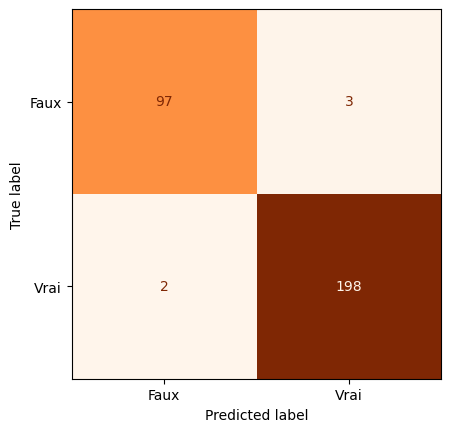

In [9]:
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay, classification_report

from sklearn.neighbors import KNeighborsClassifier

# Répéter les même étapes que pour la régression logistique mais avec le KNN.
knn = KNeighborsClassifier(n_neighbors=5) # 5 voisins les plus proches
knn.fit(X_train_scaled, y_train) # entraînement du modèle
y_pred_knn = knn.predict(X_test_scaled) # prédictions sur le jeu de test

cm_knn = confusion_matrix(y_test, y_pred_knn)
print("Matrice de confusion - KNN :")
print(cm_knn)
disp_knn = ConfusionMatrixDisplay(confusion_matrix=cm_knn, display_labels=["Faux", "Vrai"])
disp_knn.plot(colorbar=False, cmap="Oranges")
plt.show()


Matrice de confusion - Régression logistique :
[[ 98   2]
 [  1 199]]


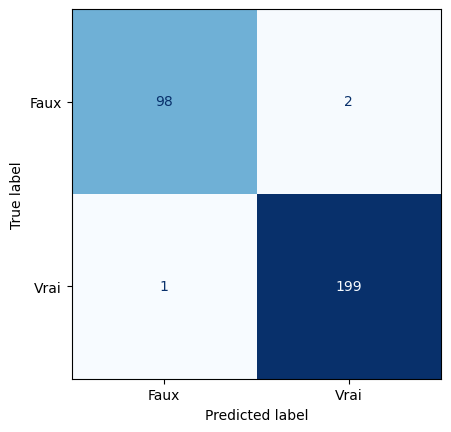

Classification report - Régression logistique :


,precision,recall,f1-score,support
False,0.989899,0.9800,0.984925,100.00
True,0.990050,0.9950,0.992519,200.00
accuracy,0.990000,0.9900,0.990000,0.99
macro avg,0.989974,0.9875,0.988722,300.00
weighted avg,0.989999,0.9900,0.989987,300.00


In [10]:
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay, classification_report

from sklearn.linear_model import LogisticRegression

# 1) Initialisez une régression logistic.
    # Quels sont les paramètres ajustables de ce modèle ?
    # Bien que vous puissez laisser la majorité d'entre eux par défaut,
    # il vaut mieux, à minima, ajuster `max_iter` pour plafonner le temps de calcul.
log_reg = LogisticRegression(max_iter=1000, random_state=42) # max_iter augmenté pour garantir la convergence (même résultat pour 1000 ou 2000)

# 2) Entrainez le modèle avec vos données X_train et y_train
log_reg.fit(X_train_scaled, y_train) # entraînement du modèle

# 3) Utiliser la régression logistique pour déterminer les vrais / faux billets de X_test.
y_pred_log = log_reg.predict(X_test_scaled) # prédictions sur le jeu de test

cm_log = confusion_matrix(y_test, y_pred_log)
print("Matrice de confusion - Régression logistique :")
print(cm_log)
disp_log = ConfusionMatrixDisplay(confusion_matrix=cm_log, display_labels=["Faux", "Vrai"])
disp_log.plot(colorbar=False, cmap="Blues")
plt.show()

print("Classification report - Régression logistique :")
display(pd.DataFrame(classification_report(y_test, y_pred_log, output_dict=True)).transpose())


Matrice de confusion - Random Forest :
[[ 98   2]
 [  1 199]]


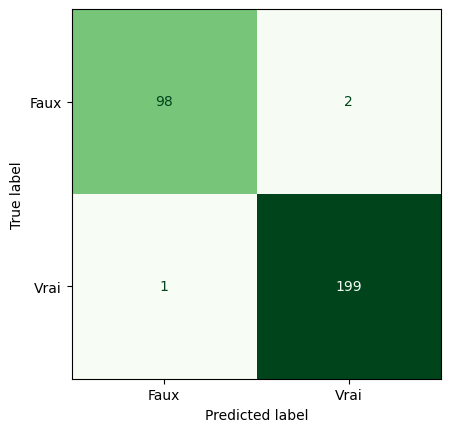

Classification report - Random Forest :


,precision,recall,f1-score,support
False,0.989899,0.9800,0.984925,100.00
True,0.990050,0.9950,0.992519,200.00
accuracy,0.990000,0.9900,0.990000,0.99
macro avg,0.989974,0.9875,0.988722,300.00
weighted avg,0.989999,0.9900,0.989987,300.00


In [11]:
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay, classification_report

from sklearn.ensemble import RandomForestClassifier

# hum... devinez ce qu'il faut faire 😁.
rf = RandomForestClassifier(random_state=42, n_estimators=100) # 100 arbres par défaut, testé avec 200 sans voir d'amélioration
rf.fit(X_train_filled, y_train) # pas besoin des données standardisées pour le Random Forest
y_pred_rf = rf.predict(X_test_filled) # prédictions sur le jeu de test

cm_rf = confusion_matrix(y_test, y_pred_rf)
print("Matrice de confusion - Random Forest :")
print(cm_rf)
disp_rf = ConfusionMatrixDisplay(confusion_matrix=cm_rf, display_labels=["Faux", "Vrai"])
disp_rf.plot(colorbar=False, cmap="Greens")
plt.show()

print("Classification report - Random Forest :")
display(pd.DataFrame(classification_report(y_test, y_pred_rf, output_dict=True)).transpose())


In [12]:
from sklearn.cluster import KMeans

# Attention ! Cet algo est très différents de ceux utilisés précédemment.
# Peux-tu voir les différences ?
# Du coup, cet algo est-il utile (voir pertinent) pour cette étude ?
kmeans = KMeans(n_clusters=2, random_state=42) # 2 clusters : vrai / faux
kmeans.fit(X_train_scaled) # entraînement (pas de y, non supervisé)

labels_train = kmeans.labels_ # cluster attribué à chaque billet du train

print("Répartition des vrais / faux billets dans les clusters du train :")
display(pd.crosstab(labels_train, y_train, rownames=["cluster"], colnames=["is_genuine"]))

Répartition des vrais / faux billets dans les clusters du train :


is_genuine,False,True
cluster,,
0,388,7
1,12,793


In [13]:
correspondance_clusters = {}
y_train_reset = y_train.reset_index(drop=True)
for cluster_id in range(2):
    classes_du_cluster = y_train_reset[labels_train == cluster_id]
    correspondance_clusters[cluster_id] = classes_du_cluster.mode().iloc[0]

print("Correspondance retenue entre clusters et classes :")
for cluster_id, classe in correspondance_clusters.items():
    etiquette = "vrai billet" if classe else "faux billet"
    print(f"cluster {cluster_id} -> {etiquette}")

labels_test = kmeans.predict(X_test_scaled)
y_pred_kmeans = pd.Series(labels_test).map(correspondance_clusters).to_numpy()

print("Répartition des clusters sur le jeu de test :")
display(pd.DataFrame({
    "cluster": labels_test,
    "prediction_kmeans": pd.Series(y_pred_kmeans).map({True: "vrai", False: "faux"})
}).value_counts().rename("effectif").reset_index())

Correspondance retenue entre clusters et classes :
cluster 0 -> faux billet
cluster 1 -> vrai billet
Répartition des clusters sur le jeu de test :


,cluster,prediction_kmeans,effectif
0,1,vrai,200
1,0,faux,100


Réponse à la question dans le code:

**K-means** est non supervisé, contrairement à la **régression logistique**, au **KNN** et au **Random Forest** qui sont supervisés.
Il n’utilise pas directement la cible is_genuine pour apprendre.
Il cherche seulement à former des groupes d’observations similaires (cluster).

Pour l’utiliser ici, on est obligé de rattacher ensuite chaque cluster à une classe, ce qui est moins naturel qu’un vrai classifieur.
Donc :

oui, il peut être utile pour explorer la structure des données,
mais non, il est moins pertinent que les modèles supervisés pour cette étude, parce que notre objectif est une prédiction binaire connue à l’avance (vrai ou faux), et on possède déjà les labels.

### Complément sur les clusters K-means

Pour aller un peu plus loin, on peut regarder la **forme générale** des clusters obtenus, leur **répartition** et leurs **caractéristiques moyennes**.
Cela permet de mieux justifier ce que K-means apporte, même s'il reste moins pertinent qu'un modèle supervisé pour notre objectif final.

In [14]:
from sklearn.metrics import silhouette_score

print("Silhouette score du K-means :", round(silhouette_score(X_train_scaled, labels_train), 3))

Silhouette score du K-means : 0.345


In [15]:
kmeans_train_df_brute = X_train_filled.reset_index(drop=True).copy()
kmeans_train_df_brute["cluster"] = labels_train
kmeans_train_df_brute["is_genuine"] = y_train.reset_index(drop=True)

for cluster_id in sorted(kmeans_train_df_brute["cluster"].unique()):
    print(f"\nCluster {cluster_id}")
    display(kmeans_train_df_brute[kmeans_train_df_brute["cluster"] == cluster_id])


Cluster 0


,diagonal,height_left,height_right,margin_low,margin_up,length,cluster,is_genuine
11,171.72,104.06,103.80,5.69,3.64,111.77,0,False
13,171.87,104.21,103.82,4.81,3.12,112.06,0,False
17,172.00,104.17,104.44,4.72,3.40,111.17,0,False
19,171.62,104.21,103.99,5.50,3.45,111.35,0,False
20,172.27,104.06,104.24,5.43,3.35,110.29,0,False
...,...,...,...,...,...,...,...,...
1181,172.12,104.18,104.31,5.36,3.31,111.43,0,False
1184,171.86,104.49,103.87,5.21,3.60,111.11,0,False
1189,172.37,104.52,104.37,5.36,3.26,111.27,0,False
1193,171.53,104.03,104.05,5.77,3.22,111.93,0,False



Cluster 1


,diagonal,height_left,height_right,margin_low,margin_up,length,cluster,is_genuine
0,171.81,103.22,103.92,3.99,3.06,113.32,1,True
1,171.94,104.09,103.28,3.98,3.13,113.53,1,True
2,172.13,103.35,104.17,4.23,3.27,113.06,1,True
3,172.08,104.19,104.03,4.11,2.99,113.50,1,True
4,172.21,103.48,104.04,4.40,3.00,113.15,1,True
...,...,...,...,...,...,...,...,...
1194,172.30,103.82,104.09,4.18,3.22,113.23,1,True
1195,171.24,103.81,103.74,4.69,3.29,113.53,1,True
1196,172.08,104.49,103.96,4.38,3.14,113.42,1,True
1198,172.13,103.76,103.85,3.65,3.24,112.92,1,True


In [16]:
kmeans_train_df = X_train_filled.reset_index(drop=True).copy()
kmeans_train_df["cluster"] = labels_train
kmeans_train_df["type_billet"] = y_train_reset.map({True: "vrai", False: "faux"})

print("Répartition des types de billets par cluster :")
repartition_clusters = kmeans_train_df.groupby(["cluster", "type_billet"]).size().unstack(fill_value=0)
display(repartition_clusters)

Répartition des types de billets par cluster :


type_billet,faux,vrai
cluster,,
0,388,7
1,12,793


In [17]:
print("Caractéristiques moyennes par cluster :")
caracteristiques_clusters = kmeans_train_df.groupby("cluster")[[
    "diagonal", "height_left", "height_right", "margin_low", "margin_up", "length"
]].mean().round(3)
display(caracteristiques_clusters)

centroides = pd.DataFrame(
    scaler.inverse_transform(kmeans.cluster_centers_),
    columns=["diagonal", "height_left", "height_right", "margin_low", "margin_up", "length"]
).round(3)
print("Centroïdes ramenés dans l'échelle d'origine :")
display(centroides)

Caractéristiques moyennes par cluster :


,diagonal,height_left,height_right,margin_low,margin_up,length
cluster,,,,,,
0,171.897,104.198,104.151,5.220,3.352,111.612
1,171.990,103.950,103.805,4.131,3.054,113.186


Centroïdes ramenés dans l'échelle d'origine :


,diagonal,height_left,height_right,margin_low,margin_up,length
0,171.897,104.198,104.151,5.220,3.352,111.612
1,171.990,103.950,103.805,4.131,3.054,113.186


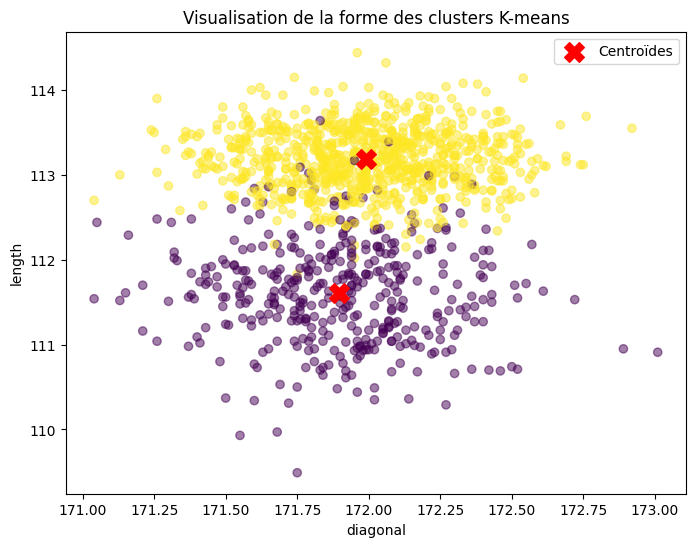

In [18]:
plt.figure(figsize=(8, 6))
plt.scatter(
    kmeans_train_df["diagonal"],
    kmeans_train_df["length"],
    c=labels_train,
    cmap="viridis",
    alpha=0.5,
)
plt.scatter(
    centroides["diagonal"],
    centroides["length"],
    c="red",
    marker="X",
    s=200,
    label="Centroïdes",
)
plt.xlabel("diagonal")
plt.ylabel("length")
plt.title("Visualisation de la forme des clusters K-means")
plt.legend()
plt.show()

In [19]:
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, roc_auc_score, confusion_matrix, ConfusionMatrixDisplay, classification_report

# C'est là qu'on voit qui sont les bons 😉!
modeles = {
    "Régression logistique": (y_pred_log, log_reg, X_test_scaled),
    "KNN": (y_pred_knn, knn, X_test_scaled),
    "Random Forest": (y_pred_rf, rf, X_test_filled),
    "K-means": (y_pred_kmeans, None, None),
}

resultats = []
for nom, (y_pred, modele, X_eval) in modeles.items():
    ligne = {
        "Modèle": nom,
        "Accuracy": accuracy_score(y_test, y_pred),
        "Précision (Faux)": precision_score(y_test, y_pred, pos_label=False),
        "Recall (Faux)": recall_score(y_test, y_pred, pos_label=False),
        "F1-score (Faux)": f1_score(y_test, y_pred, pos_label=False),
    }
    if modele is not None:
        proba_true = modele.predict_proba(X_eval)[:, 1]
        ligne["ROC AUC"] = roc_auc_score(y_test, proba_true)
    else:
        ligne["ROC AUC"] = np.nan
    resultats.append(ligne)

resultats_df = pd.DataFrame(resultats).sort_values(by="Recall (Faux)", ascending=False).reset_index(drop=True)
display(resultats_df)







,Modèle,Accuracy,Précision (Faux),Recall (Faux),F1-score (Faux),ROC AUC
0,Régression logistique,0.990000,0.989899,0.98,0.984925,0.99955
1,Random Forest,0.990000,0.989899,0.98,0.984925,0.99930
2,K-means,0.986667,0.980000,0.98,0.980000,NaN
3,KNN,0.983333,0.979798,0.97,0.974874,0.99720


Meilleur modèle : Régression logistique


,Prédit: Faux,Prédit: Vrai
Réel: Faux,98,2
Réel: Vrai,1,199


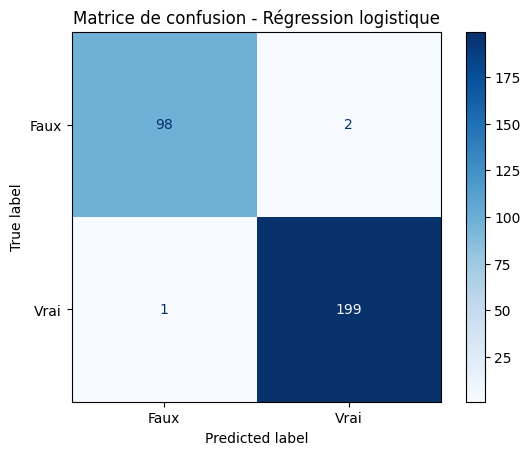

,precision,recall,f1-score,support
False,0.989899,0.9800,0.984925,100.00
True,0.990050,0.9950,0.992519,200.00
accuracy,0.990000,0.9900,0.990000,0.99
macro avg,0.989974,0.9875,0.988722,300.00
weighted avg,0.989999,0.9900,0.989987,300.00


In [20]:
meilleur_modele = resultats_df.iloc[0]["Modèle"]
print("Meilleur modèle :", meilleur_modele)

if meilleur_modele == "Régression logistique":
    y_pred_best = y_pred_log
    best_model = log_reg
    X_eval_best = X_test_scaled
elif meilleur_modele == "KNN":
    y_pred_best = y_pred_knn
    best_model = knn
    X_eval_best = X_test_scaled
elif meilleur_modele == "Random Forest":
    y_pred_best = y_pred_rf
    best_model = rf
    X_eval_best = X_test_filled
else:
    y_pred_best = y_pred_kmeans
    best_model = None
    X_eval_best = None

cm = confusion_matrix(y_test, y_pred_best)
display(pd.DataFrame(cm, index=["Réel: Faux", "Réel: Vrai"], columns=["Prédit: Faux", "Prédit: Vrai"]))
ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=["Faux", "Vrai"]).plot(cmap="Blues")
plt.title(f"Matrice de confusion - {meilleur_modele}")
plt.show()

display(pd.DataFrame(classification_report(y_test, y_pred_best, output_dict=True)).transpose())

,Prédit: Faux,Prédit: Vrai
Réel: Faux,98,2
Réel: Vrai,1,199


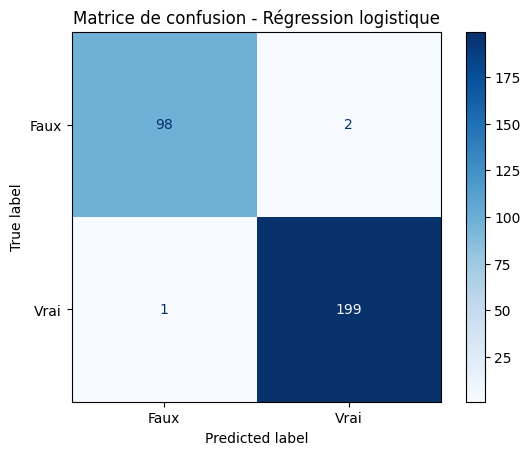

,precision,recall,f1-score,support
False,0.989899,0.9800,0.984925,100.00
True,0.990050,0.9950,0.992519,200.00
accuracy,0.990000,0.9900,0.990000,0.99
macro avg,0.989974,0.9875,0.988722,300.00
weighted avg,0.989999,0.9900,0.989987,300.00


In [21]:
display(pd.DataFrame(cm, index=["Réel: Faux", "Réel: Vrai"], columns=["Prédit: Faux", "Prédit: Vrai"]))
ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=["Faux", "Vrai"]).plot(cmap="Blues")
plt.title(f"Matrice de confusion - {meilleur_modele}")
plt.show()

display(pd.DataFrame(classification_report(y_test, y_pred_best, output_dict=True)).transpose())

# Choix du seuil de décision

Le modèle renvoie des probabilités. On peut donc tester plusieurs seuils de décision, puis choisir celui qui colle le mieux au besoin métier.

Ici, le besoin métier est clair : il vaut mieux bloquer quelques vrais billets supplémentaires que laisser passer un seul faux billet.


In [22]:
true_index = list(log_reg.classes_).index(True)
proba_true = log_reg.predict_proba(X_test_scaled)[:, true_index]

seuils = [0.50, 0.55, 0.60, 0.65, 0.70, 0.75, 0.80, 0.85, 0.90, 0.95]

In [23]:
resultats_seuils = []

for seuil in seuils:
    y_pred_seuil = proba_true >= seuil
    resultats_seuils.append(
        {
            "Seuil": seuil,
            "Précision (Faux)": precision_score(y_test, y_pred_seuil, pos_label=False),
            "Recall (Faux)": recall_score(y_test, y_pred_seuil, pos_label=False),
            "F1-score (Faux)": f1_score(y_test, y_pred_seuil, pos_label=False),
            "Faux laissés passer": int(((~y_test) & y_pred_seuil).sum()),
            "Vrais classés faux": int((y_test & (~y_pred_seuil)).sum()),
        }
    )

resultats_seuils_df = pd.DataFrame(resultats_seuils)
display(resultats_seuils_df)

print("seuil retenu = 0.75, car 0.7 est le seuil minimum pour ne pas avoir de faux billet et vu que 0.70 == 0.75 autant jouer la sécurité")

,Seuil,Précision (Faux),Recall (Faux),F1-score (Faux),Faux laissés passer,Vrais classés faux
0,0.50,0.989899,0.98,0.984925,2,1
1,0.55,0.990000,0.99,0.990000,1,1
2,0.60,0.990000,0.99,0.990000,1,1
3,0.65,0.980198,0.99,0.985075,1,2
4,0.70,0.970874,1.00,0.985222,0,3
5,0.75,0.970874,1.00,0.985222,0,3
6,0.80,0.961538,1.00,0.980392,0,4
7,0.85,0.952381,1.00,0.975610,0,5
8,0.90,0.909091,1.00,0.952381,0,10
9,0.95,0.854701,1.00,0.921659,0,17


seuil retenu = 0.75, car 0.7 est le seuil minimum pour ne pas avoir de faux billet et vu que 0.70 == 0.75 autant jouer la sécurité


Seuil retenu : 0.75


,Seuil,Précision (Faux),Recall (Faux),F1-score (Faux)
0,0.75,0.970874,1.0,0.985222


,Prédit: Faux,Prédit: Vrai
Réel: Faux,100,0
Réel: Vrai,3,197


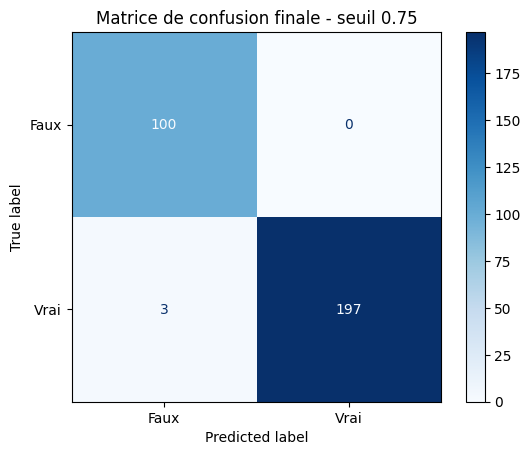

,precision,recall,f1-score,support
False,0.970874,1.0000,0.985222,100.00
True,1.000000,0.9850,0.992443,200.00
accuracy,0.990000,0.9900,0.990000,0.99
macro avg,0.985437,0.9925,0.988832,300.00
weighted avg,0.990291,0.9900,0.990036,300.00


In [24]:


seuil_choisi = 0.75

print("Seuil retenu :", seuil_choisi)

y_pred_final = proba_true >= seuil_choisi

display(pd.DataFrame([{
    "Seuil": seuil_choisi,
    "Précision (Faux)": precision_score(y_test, y_pred_final, pos_label=False),
    "Recall (Faux)": recall_score(y_test, y_pred_final, pos_label=False),
    "F1-score (Faux)": f1_score(y_test, y_pred_final, pos_label=False),
}]))

cm_final = confusion_matrix(y_test, y_pred_final)
display(pd.DataFrame(cm_final, index=["Réel: Faux", "Réel: Vrai"], columns=["Prédit: Faux", "Prédit: Vrai"]))
ConfusionMatrixDisplay(confusion_matrix=cm_final, display_labels=["Faux", "Vrai"]).plot(cmap="Blues")
plt.title(f"Matrice de confusion finale - seuil {seuil_choisi:.2f}")
plt.show()

display(pd.DataFrame(classification_report(y_test, y_pred_final, output_dict=True)).transpose())

# Sauvegarde du meilleur modèle

**_ATTENTION_** :
```
Sauvegarder un modèle implique de sauvegarder aussi les étapes de préprocessing des données.
Dans votre cas, vous devez donc inclure, à minima, votre StandardScaler.
```
Voir [`make_pipeline`](https://scikit-learn.org/stable/modules/generated/sklearn.pipeline.make_pipeline.html) pour plus d'infos.


In [25]:
from sklearn.pipeline import make_pipeline
import joblib

# Utilisez make_pipeline pour inclure toutes les étapes nécessaires
# à la prédiction de si un billet est vrai ou faux.
final_pipeline = make_pipeline(
    imputer, #déclaré plus haut lors du choix de l'imputer
    StandardScaler(),
    LogisticRegression(max_iter=1000, random_state=42)
)
final_pipeline.fit(X_train, y_train)

# Sauvegardez votre modèle à l'aide de la librairie joblib.
modele_final = {
    "pipeline": final_pipeline,
    "threshold": seuil_choisi,
}
joblib.dump(modele_final, "../best_billet_model_from_template.joblib")
print("✅ Modèle sauvegardé")
print(f"Seuil sauvegardé : {seuil_choisi:.2f}")

model_loaded = joblib.load("../best_billet_model_from_template.joblib")
pipeline_loaded = model_loaded["pipeline"]
threshold_loaded = model_loaded["threshold"]
TEST_PATH = os.path.join("..", "data", "billets_test.csv")
if os.path.exists(TEST_PATH):
    df_test = pd.read_csv(TEST_PATH, sep=";")
    X_test_file = df_test[["diagonal", "height_left", "height_right", "margin_low", "margin_up", "length"]]
    print("\nTest de rechargement sur billets_test.csv :")
    print(pipeline_loaded.predict(X_test_file))
    if hasattr(pipeline_loaded, "predict_proba"):
        print("Seuil rechargé :", round(threshold_loaded, 2))
        print(pipeline_loaded.predict_proba(X_test_file).round(3))
        resultats_test = df_test.copy()
        resultats_test["proba_faux"] = pipeline_loaded.predict_proba(X_test_file)[:, 0]
        resultats_test["proba_vrai"] = pipeline_loaded.predict_proba(X_test_file)[:, 1]
        resultats_test["prediction"] = np.where(
            resultats_test["proba_vrai"] >= threshold_loaded,
            "vrai",
            "faux"
        )
        display(resultats_test[["id", "proba_faux", "proba_vrai", "prediction"]])
else:
    print("Fichier de test introuvable :", TEST_PATH)


✅ Modèle sauvegardé
Seuil sauvegardé : 0.75


KeyError: "None of [Index(['diagonal', 'height_left', 'height_right', 'margin_low', 'margin_up',\n       'length'],\n      dtype='str')] are in the [columns]"